In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

# Ejercicio de clasificación usando kNN

Tenemos el dataset de incumplimiento de clientes para una compañía de tarjetas de crédito. De cada cliente se tiene el balance que le llegó de la tarjeta, si es un estudiante universitario o no y el sueldo anual. Además, contamos si el cliente incumplió el pago o no. Este dataset es el usado en regresión logística en Inteligencia Artificial.

In [2]:
default_df = pd.read_csv("./datasets/Default.csv")

Como siempre, vemos un poco nuestros datos

In [ ]:
default_df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [4]:
default_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  str    
 1   student  10000 non-null  str    
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB


In [5]:
default_df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


Convirtamos a las columnas **default** y **student** en columnas numéricas

In [6]:
default_df["Incumplimiento"] = default_df["default"].apply(
    lambda x: "Sí" if x == "Yes" else "No"
)
default_df["Estudiante"] = default_df["student"].apply(
    lambda x: "Sí" if x == "Yes" else "No"
)

default_df["default"] = default_df["default"].apply(lambda x: 1 if x == "Yes" else 0)
default_df["student"] = default_df["student"].apply(lambda x: 1 if x == "Yes" else 0)

In [7]:
default_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   default         10000 non-null  int64  
 1   student         10000 non-null  int64  
 2   balance         10000 non-null  float64
 3   income          10000 non-null  float64
 4   Incumplimiento  10000 non-null  str    
 5   Estudiante      10000 non-null  str    
dtypes: float64(2), int64(2), str(2)
memory usage: 468.9 KB


Veamos la clase (default):

In [8]:
default_df.default.value_counts()

default
0    9667
1     333
Name: count, dtype: int64

Obsérvese que tenemos una gran desproporción de clases. Tenemos 3.3% de observaciónes de personas que no pagaron. 

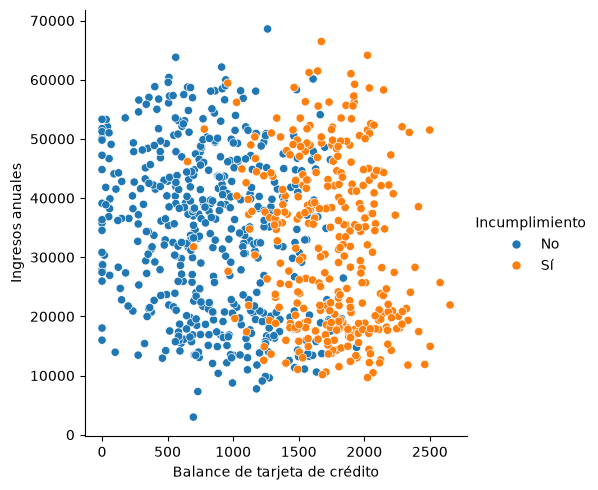

In [9]:
#Hacemos esto para poder graficar y poder visualizar mejor
df_sample_no_default = default_df[default_df["default"] == 0].copy()
df_sample_no_default = df_sample_no_default.sample(frac=0.05)
df_sample_default = default_df[default_df["default"] == 1].copy()

g = sns.relplot(
    data=pd.concat([df_sample_no_default, df_sample_default]),
    x="balance",
    y="income",
    hue="Incumplimiento",
    kind="scatter",
    legend=True,
)
plt.xlabel("Balance de tarjeta de crédito")
plt.ylabel("Ingresos anuales");

### Modelo de regresión logística

Para tener un punto de comparación, usemos el modelo de regresión logística realizado en Inteligencia Artificial.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
# como siempre vamos separando nuestras variables predictoras de la variable a predecir
X = default_df.loc[:, ["balance", "income", "student"]].to_numpy()
y = default_df.loc[:, "default"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

In [14]:
model_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=0, class_weight="balanced"))
])

# Ajustamos el pipeline completo
model_logistic.fit(X_train, y_train)
# Predecimos directamente
y_pred = model_logistic.predict(X_test)

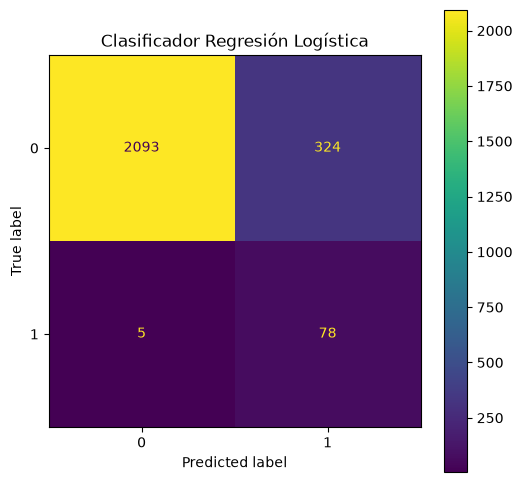

In [15]:
# Creamos la matriz de confusión
cm_logistic = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic,
                              display_labels=model_logistic.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador Regresión Logística");

In [16]:
# Midamos la sensibilidad y especificidad
print("Clasificador Regresión Logística")
print("-" * 32)

# Sensibilidad (TPR) y Especificidad (TNR)
# Usamos .sum() en lugar de np.sum() para evitar advertencias de tipado
P = cm_logistic[1, :].sum()
N = cm_logistic[0, :].sum()
TP = cm_logistic[1, 1]
TN = cm_logistic[0, 0]

TPR = TP / P
TNR = TN / N
balanced_accuracy = (TPR + TNR) / 2

# Otras métricas usando sklearn (calculadas de forma más limpia)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Imprimimos las métricas con formato de 4 decimales y alineadas
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {balanced_accuracy:.4f}")
print(f"Precisión:             {precision:.4f}")
print(f"Recuperación (Recall): {recall:.4f}")
print(f"F1-score:              {f1:.4f}")

Clasificador Regresión Logística
--------------------------------
Sensibilidad (Recall): 0.9398
Especificidad:         0.8659
Exactitud balanceada:  0.9029
Precisión:             0.1940
Recuperación (Recall): 0.9398
F1-score:              0.3216


## Clasificador KNN

Vamos a usar el clasificador KNN de [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). Para este ejemplo, vamos a usar el mismo dataset de la regresión logistica.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Creamos el pipeline que primero escala los datos y luego aplica KNN
classifier_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=23, metric="minkowski", p=2))
])

# Entrenamos el pipeline completo
classifier_knn.fit(X_train, y_train)

#Evaluamos
y_pred  = classifier_knn.predict(X_test)

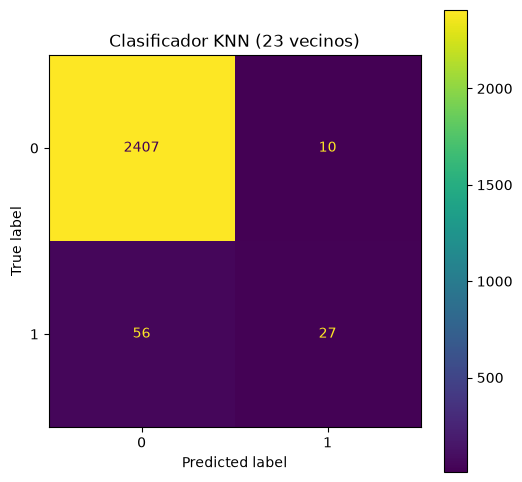

In [18]:
cm_knn = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=classifier_knn.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador KNN (23 vecinos)");

In [19]:
# Midamos la sensibilidad y especificidad
print("Clasificador KNN (23 vecinos)")
print("-" * 29)

# Sensibilidad (TPR) y Especificidad (TNR)
# Usamos .sum() en lugar de np.sum() para evitar advertencias de tipado
P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR + TNR) / 2

# Otras métricas usando sklearn (calculadas de forma más limpia)
precision_knn = precision_score(y_test, y_pred, zero_division=0)
recall_knn = recall_score(y_test, y_pred, zero_division=0)
f1_knn = f1_score(y_test, y_pred, zero_division=0)

# Imprimimos las métricas con formato de 4 decimales y alineadas
print(f"Sensibilidad (Recall): {TPR_knn:.4f}")
print(f"Especificidad:         {TNR_knn:.4f}")
print(f"Exactitud balanceada:  {balanced_accuracy_knn:.4f}")
print(f"Precisión:             {precision_knn:.4f}")
print(f"Recuperación (Recall): {recall_knn:.4f}")
print(f"F1-score:              {f1_knn:.4f}")

Clasificador KNN (23 vecinos)
-----------------------------
Sensibilidad (Recall): 0.3253
Especificidad:         0.9959
Exactitud balanceada:  0.9029
Precisión:             0.7297
Recuperación (Recall): 0.3253
F1-score:              0.4500


Veamos la frontera de decisión

In [21]:
X = default_df.loc[:, ["balance", "income"]].to_numpy()
y = default_df.loc[:, "default"].to_numpy()
X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

classifier_knn_two = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=31, metric="minkowski", p=2))
])
classifier_knn_two.fit(X_train_two, y_train_two)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


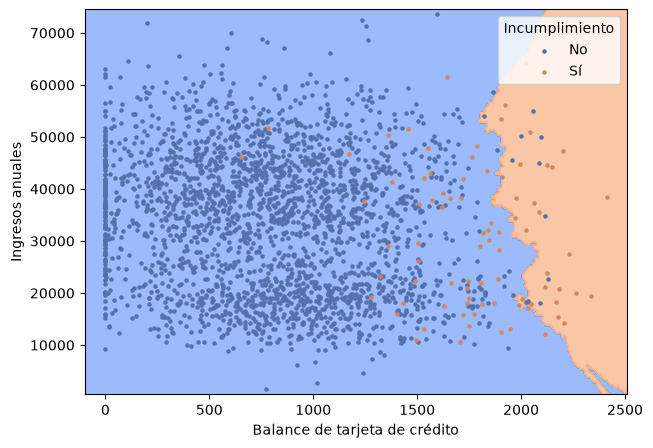

In [27]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_test_two, y_test_two

# Creamos la malla en la escala real (ajustamos el step para cada eje)
# Usamos un paso de 10 para balance y de 500 para ingresos para que la 
# grilla sea rápida de calcular
X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 100, X_set[:, 0].max() + 100, 10),
    np.arange(X_set[:, 1].min() - 1000, X_set[:, 1].max() + 1000, 500)
)

X_cont = np.array([X1.ravel(), X2.ravel()]).T

# 3. Gráfico de contorno
plt.figure(figsize=(7, 5))
plt.contourf(
    X1, X2, classifier_knn_two.predict(X_cont).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(['#7aa5fb', '#f8b389'])
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Graficar los puntos de prueba
lab = ["No", "Sí"]
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        color=ListedColormap(['#5471ab', '#d1885c'])(i), label=lab[i],
        s=5
    )

plt.xlabel('Balance de tarjeta de crédito') 
plt.ylabel('Ingresos anuales') 
plt.legend(title="Incumplimiento")

plt.show()
